AI Tool Usage by Indian College Students 2025

Introduction:-


Artificial Intelligence (AI) is increasingly transforming the educational landscape by influencing how students learn, complete assignments, and enhance academic performance. This project is based on a dataset containing information from 496 Indian college students use AI tools (e.g., ChatGPT, Gemini, Copilot) in academics.

The dataset includes 16 attributes which captures key aspects of students’ interactions with AI tools, including their preferred AI platforms, daily usage habits, trust levels, and perceived impact on grades.

The aim of analyzing this data to explore patterns of AI adoption in education, identify the most common use cases, and evaluate the overall impact of AI tools on academic performance.It also provides insights into the technological accessibility of students, such as the devices they use and the quality of internet access available to them.

Import the necessary libraries


In [7]:
#remove the warning message
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

Import dataset

In [2]:
df=pd.read_csv("C:\Datascience\Project\Students.csv")

Display the 1st 5 rows

In [3]:
print(df.head())

  Student_Name                                      College_Name       Stream  \
0        Aarav       Indian Institute of Information Technology   Engineering   
1       Vivaan   Government Ram Bhajan Rai NES College, Jashpur      Commerce   
2       Aditya     Dolphin PG Institute of BioMedical & Natural       Science   
3       Vihaan  Shaheed Rajguru College of Applied Sciences for          Arts   
4        Arjun                   Roorkee College of Engineering       Science   

   Year_of_Study AI_Tools_Used  Daily_Usage_Hours  \
0              4        Gemini                0.9   
1              2       ChatGPT                3.4   
2              2       Copilot                3.6   
3              2       Copilot                2.9   
4              1        Gemini                0.9   

                       Use_Cases  Trust_in_AI_Tools  Impact_on_Grades  \
0       Assignments, Coding Help                  2                 2   
1            Learning new topics                

Display the last 5 rows

In [5]:
print(df.tail())

     Student_Name                                  College_Name       Stream  \
3609       Ishaan           St. Mira's College for Girls, Pune      Commerce   
3610        Rudra                  Roorkee College of Pharmacy      Pharmacy   
3611        Dhruv                       Bahona College, Jorhat   Agriculture   
3612        Kabir  Sree Chitra Thirunal College of Engineering   Engineering   
3613       Atharv              Poona College of Pharmacy, Pune      Pharmacy   

      Year_of_Study     AI_Tools_Used  Daily_Usage_Hours  \
3609              1  ChatGPT, Copilot                4.3   
3610              3           Copilot                3.0   
3611              3            Gemini                2.7   
3612              4            Gemini                2.7   
3613              3           Copilot                0.9   

                          Use_Cases  Trust_in_AI_Tools  Impact_on_Grades  \
3609  Doubt Solving, Resume Writing                  2                 2   
3610  

Data cleaning


In [6]:
#for checking there are any missing values
print(df.isna().sum())

Student_Name                    0
College_Name                    0
Stream                          0
Year_of_Study                   0
AI_Tools_Used                   0
Daily_Usage_Hours               0
Use_Cases                       0
Trust_in_AI_Tools               0
Impact_on_Grades                0
Do_Professors_Allow_Use         0
Preferred_AI_Tool               0
Awareness_Level                 0
Willing_to_Pay_for_Access       0
State                        1614
Device_Used                     0
Internet_Access                 0
dtype: int64


Fill state column with unknown


In [7]:
df['State']=df['State'].fillna('unknown')

In [8]:
#for checking there are any missing values
print(df.isna().sum())

Student_Name                 0
College_Name                 0
Stream                       0
Year_of_Study                0
AI_Tools_Used                0
Daily_Usage_Hours            0
Use_Cases                    0
Trust_in_AI_Tools            0
Impact_on_Grades             0
Do_Professors_Allow_Use      0
Preferred_AI_Tool            0
Awareness_Level              0
Willing_to_Pay_for_Access    0
State                        0
Device_Used                  0
Internet_Access              0
dtype: int64


In [9]:
print(df['State'].head(15))

0     Uttar pradesh
1      Chhattisgarh
2       Uttarakhand
3         Delhi ncr
4       Uttarakhand
5            Punjab
6        Chandigarh
7        Puducherry
8         Rajasthan
9         Meghalaya
10       Puducherry
11        Jharkhand
12    Uttar pradesh
13      Maharashtra
14       Tamil nadu
Name: State, dtype: object


In [10]:
print(df['State'].tail(15))

3599    unknown
3600    unknown
3601    unknown
3602    unknown
3603    unknown
3604    unknown
3605    unknown
3606    unknown
3607    unknown
3608    unknown
3609    unknown
3610    unknown
3611    unknown
3612    unknown
3613    unknown
Name: State, dtype: object


In [5]:
#check for duplicate rows
df.duplicated().sum()

0

Data understanding

In [14]:
#basic info about the dataset
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3614 entries, 0 to 3613
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_Name               3614 non-null   object 
 1   College_Name               3614 non-null   object 
 2   Stream                     3614 non-null   object 
 3   Year_of_Study              3614 non-null   int64  
 4   AI_Tools_Used              3614 non-null   object 
 5   Daily_Usage_Hours          3614 non-null   float64
 6   Use_Cases                  3614 non-null   object 
 7   Trust_in_AI_Tools          3614 non-null   int64  
 8   Impact_on_Grades           3614 non-null   int64  
 9   Do_Professors_Allow_Use    3614 non-null   object 
 10  Preferred_AI_Tool          3614 non-null   object 
 11  Awareness_Level            3614 non-null   int64  
 12  Willing_to_Pay_for_Access  3614 non-null   object 
 13  State                      3614 non-null   objec

In [15]:
#use summary statistics to understand distribution
print(df.describe())

       Year_of_Study  Daily_Usage_Hours  Trust_in_AI_Tools  Impact_on_Grades  \
count    3614.000000        3614.000000        3614.000000       3614.000000   
mean        2.472883           2.559685           3.023243          0.003320   
std         1.107912           1.213319           1.436934          2.370706   
min         1.000000           0.500000           1.000000         -5.000000   
25%         2.000000           1.500000           2.000000         -2.000000   
50%         2.000000           2.600000           3.000000          0.000000   
75%         3.000000           3.600000           4.000000          2.000000   
max         4.000000           5.000000           5.000000          5.000000   

       Awareness_Level  
count      3614.000000  
mean          5.828445  
std           2.925481  
min           1.000000  
25%           3.000000  
50%           6.000000  
75%           8.000000  
max          10.000000  


In [ ]:
#1 what is the count of students across diffrent Streams
df['Stream'].value_counts()

Science             593
Engineering         505
Arts                413
Management          380
Commerce            364
Hotel-management    318
Medical             281
Agriculture         262
Pharmacy            252
Law                 246
Name: Stream, dtype: int64

In [17]:
#2 which AI tools are most commonly used
df['AI_Tools_Used'].value_counts()

ChatGPT                     626
Gemini                      612
Copilot                     585
ChatGPT, Copilot            505
ChatGPT, Gemini, Copilot    426
Gemini, Midjourney          371
Claude                      171
Other                       167
Bard                        151
Name: AI_Tools_Used, dtype: int64

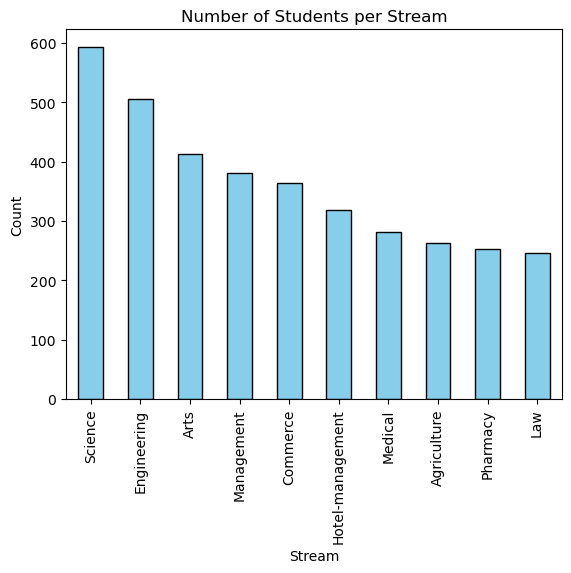

In [4]:
#3 Which stream has the highest number of students?
df['Stream'].value_counts().plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Number of Students per Stream")
plt.xlabel("Stream")
plt.ylabel("Count")
plt.show()

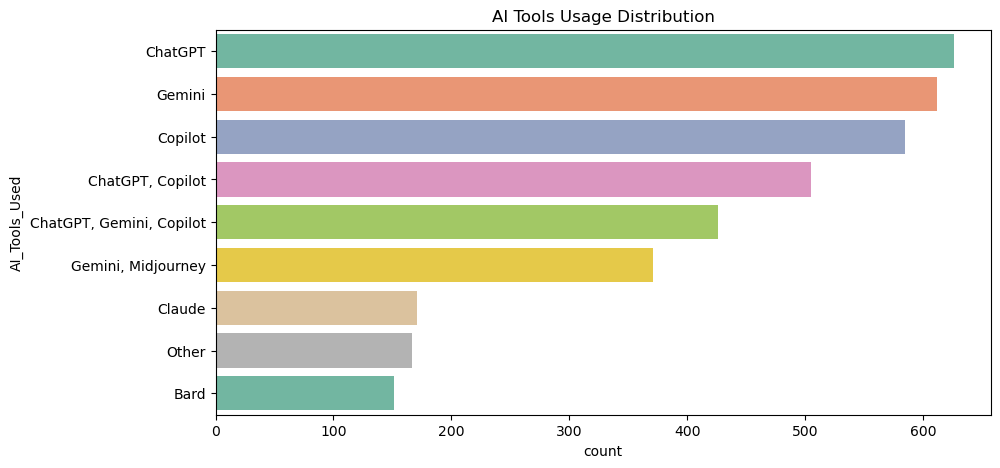

In [19]:
#4 what are the most commonly used ai tools among students?
plt.figure(figsize=(10,5))
sns.countplot(y="AI_Tools_Used", data=df, order=df['AI_Tools_Used'].value_counts().index, palette="Set2")
plt.title("AI Tools Usage Distribution")
plt.show()

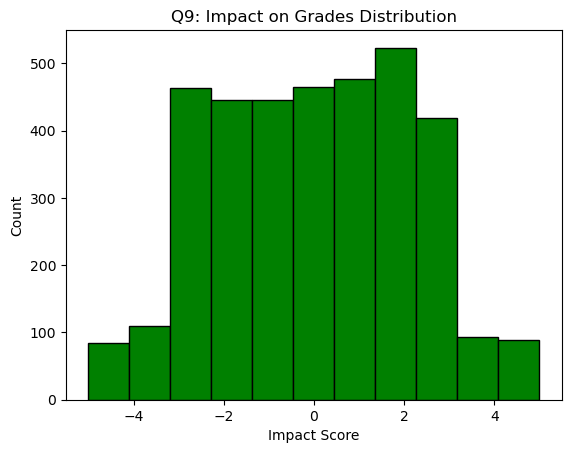

In [ ]:
 #5 what is the distribution of Impact on Grades values?
plt.hist(df['Impact_on_Grades'], bins=11, color='green', edgecolor='black')
plt.title("Q9: Impact on Grades Distribution")
plt.xlabel("Impact Score")
plt.ylabel("Count")
plt.show()

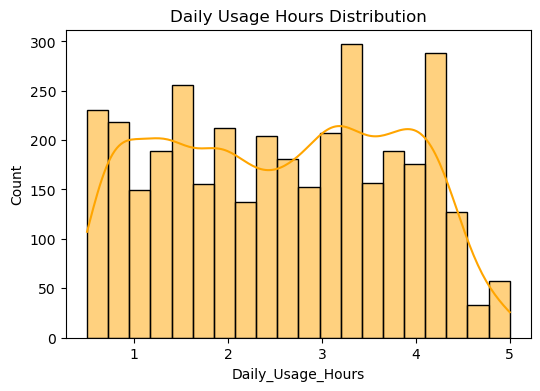

In [ ]:
#6 what is the distribution of daily usage of AI tools?
plt.figure(figsize=(6,4))
sns.histplot(df['Daily_Usage_Hours'], bins=20, kde=True, color="orange")
plt.title("Daily Usage Hours Distribution")
plt.show()

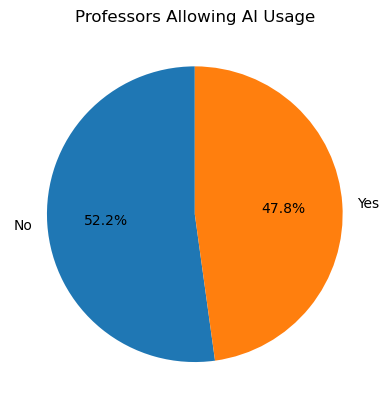

In [ ]:
#7 What percentage of students’ professors allow AI tools?
df['Do_Professors_Allow_Use'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Professors Allowing AI Usage")
plt.ylabel("")
plt.show()

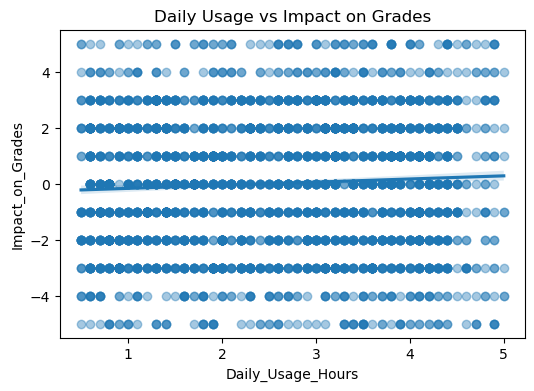

In [ ]:
#8 what is the relationship between daily usage vs impact on grades
plt.figure(figsize=(6,4))
sns.regplot(x="Daily_Usage_Hours", y="Impact_on_Grades", data=df, scatter_kws={'alpha':0.4})
plt.title("Daily Usage vs Impact on Grades")
plt.show()

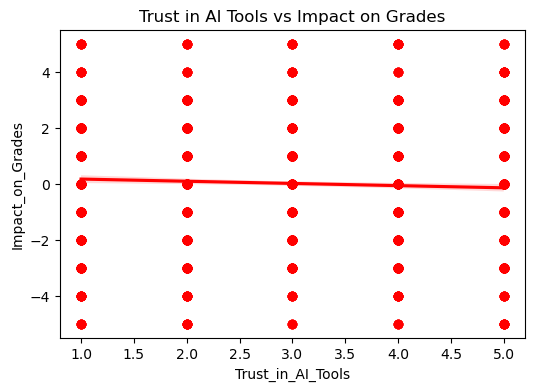

In [ ]:
#9 Does trust in AI tools correlate  with impact on grades?
plt.figure(figsize=(6,4))
sns.regplot(x="Trust_in_AI_Tools", y="Impact_on_Grades", data=df, scatter_kws={'alpha':0.4}, color="red")
plt.title("Trust in AI Tools vs Impact on Grades")
plt.show()


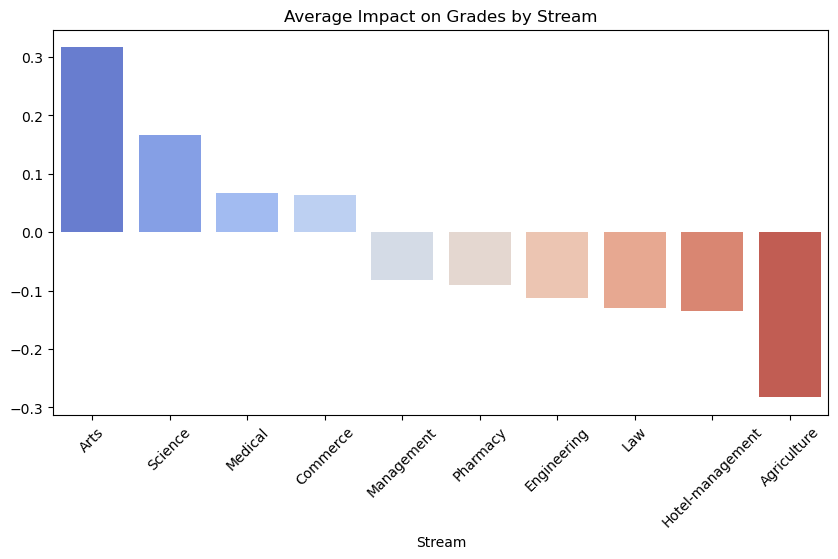

In [ ]:
#10 Does the avg impact on grades vary across different Streams?
stream_perf = df.groupby('Stream')['Impact_on_Grades'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(x=stream_perf.index, y=stream_perf.values, palette="coolwarm")
plt.title("Average Impact on Grades by Stream")
plt.xticks(rotation=45)
plt.show()


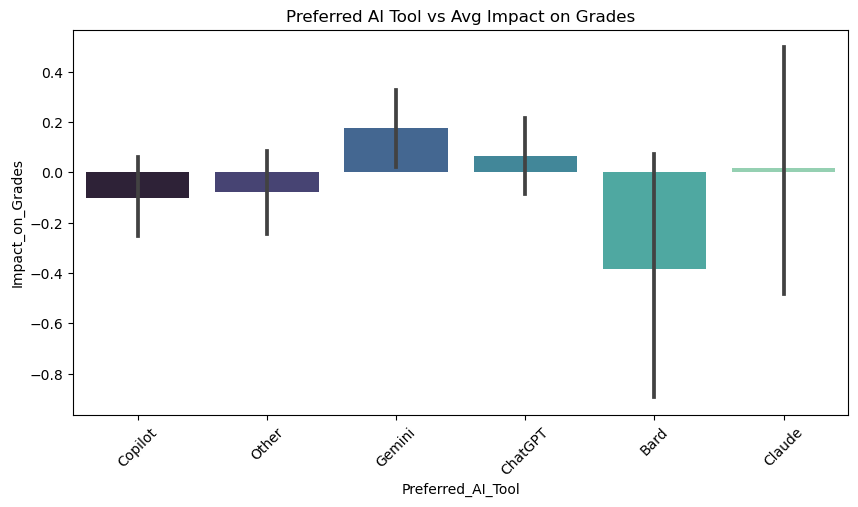

In [ ]:
#11 Which pereferred AI tool is associated with the highest average impact on grades?
plt.figure(figsize=(10,5))
sns.barplot(x="Preferred_AI_Tool", y="Impact_on_Grades", data=df, estimator=lambda x: sum(x)/len(x), palette="mako")
plt.title("Preferred AI Tool vs Avg Impact on Grades")
plt.xticks(rotation=45)
plt.show()

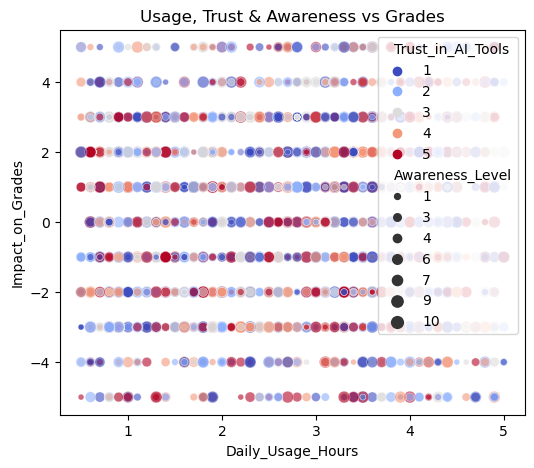

In [ ]:
#12 How does Daily usage hours,Trust in AI tools and Awareness Level together influence impacct on grades?
plt.figure(figsize=(6,5))
sns.scatterplot(x="Daily_Usage_Hours", y="Impact_on_Grades", hue="Trust_in_AI_Tools", size="Awareness_Level", data=df, palette="coolwarm", alpha=0.6)
plt.title("Usage, Trust & Awareness vs Grades")
plt.show()

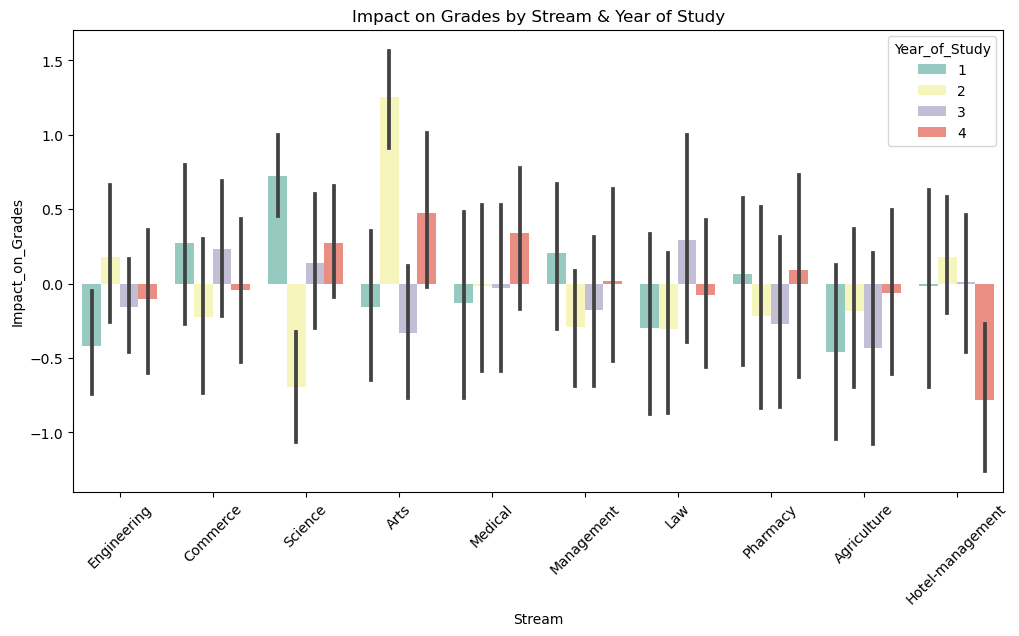

In [ ]:
#13 what is the avg impact on grades for students grouped by stream & year of study?
plt.figure(figsize=(12,6))
sns.barplot(x="Stream", y="Impact_on_Grades", hue="Year_of_Study", data=df, palette="Set3")
plt.title("Impact on Grades by Stream & Year of Study")
plt.xticks(rotation=45)
plt.show()

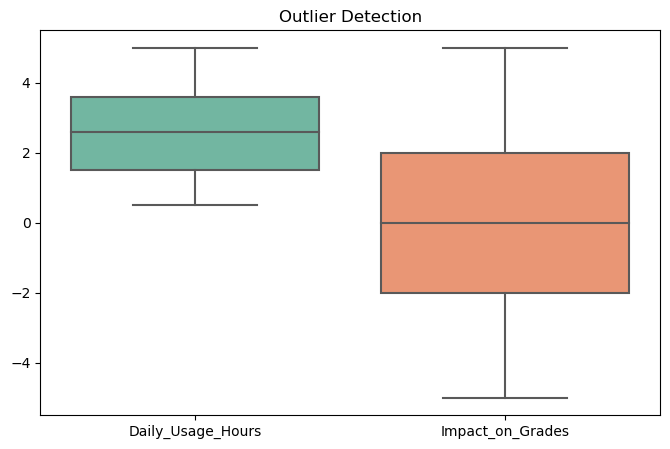

In [6]:
#14 Are there any outiers in Daily usage hours or impact on Grades?
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Daily_Usage_Hours','Impact_on_Grades']], palette="Set2")
plt.title("Outlier Detection")
plt.show()


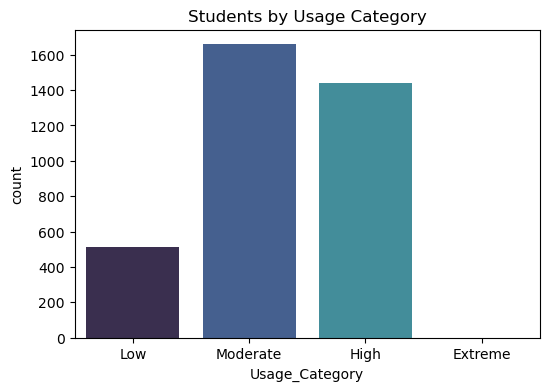

In [ ]:
#15 categorize students into usage levels (Low,Moderate,High,Extreme).How many students fall into each category?
df['Usage_Category'] = pd.cut(df['Daily_Usage_Hours'], bins=[0,1,3,5,10], labels=['Low','Moderate','High','Extreme'])
plt.figure(figsize=(6,4))
sns.countplot(x="Usage_Category", data=df, order=['Low','Moderate','High','Extreme'], palette="mako")
plt.title("Students by Usage Category")
plt.show()

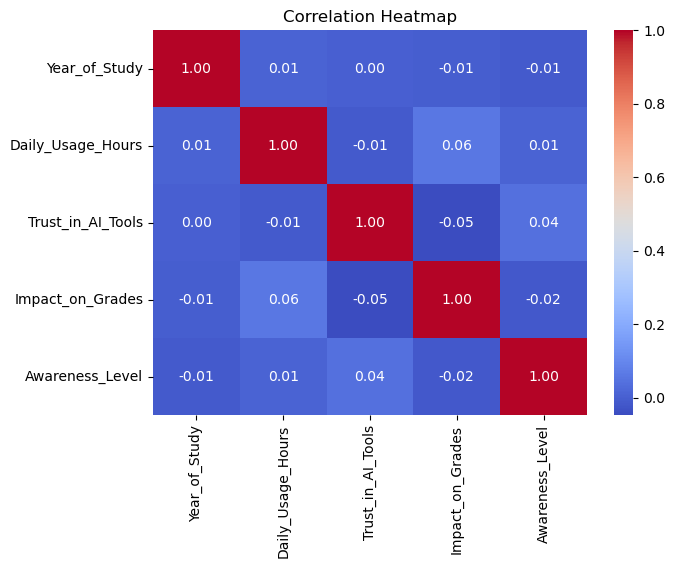

In [ ]:
#16 What are the correlations among key numerical features?which factor is most strongly linked to grade impovement?
plt.figure(figsize=(7,5))
sns.heatmap(df[['Year_of_Study','Daily_Usage_Hours','Trust_in_AI_Tools','Impact_on_Grades','Awareness_Level']].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Suggestions & Recommendations
* Usage Behavior

Observation: Avg daily usage is 2.56 hours, with Commerce, Pharmacy, and Arts students using AI more than Engineering students.

Recommendation: Universities could integrate AI skill-building modules into Engineering curricula, since their usage is lower, ensuring all streams benefit equally.

* Impact on Academic Performance

Observation: ChatGPT (+0.26) and Gemini (+0.21) show a positive grade impact, while Copilot, Bard, and Claude show slightly negative or neutral impacts.

Recommendation: Encourage guided usage of ChatGPT/Gemini in assignments and projects. Institutions may provide training workshops on effective AI tool usage to avoid misuse that negatively affects grades.

* Trust & Awareness Gap

Observation: Trust in AI Tools is spread across the scale (many students still at level 1–2), and correlations with awareness are very weak (0.04).

Recommendation: Launch awareness sessions, hackathons, and demo events to showcase the reliability and limitations of AI. Increase critical thinking training to reduce blind trust or skepticism.

* Professor & Policy Factors

Observation: In Science, 56% professors restrict AI, while Hotel-Management and Medical streams are more open.

Recommendation: Create balanced AI usage policies where AI can be used for support (e.g., doubt solving, coding help) but not as a substitute for learning. Provide faculty training to align teaching practices.

* Device & Accessibility

Observation: Laptop is most common (1336), but many still rely on Mobiles/Tablets. Internet quality has only a minor effect on usage.

Recommendation: Universities should expand computer lab facilities or offer AI-powered mobile apps optimized for low-bandwidth conditions to ensure equal access.